In [1]:
import sklearn

print(sklearn.__version__)

1.9.0


In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt 
import pandas as pd

import seaborn as sns

from sklearn.datasets import fetch_california_housing

RANDOM_STATE = 42 # setie el valor de la semilla

sns.set_theme(style="whitegrid",context="notebook") #puse como quiero que se vea mi seaborn

In [3]:
 # ACTIVIDAD 2
df_origin=fetch_california_housing(as_frame=True)
df=df_origin.frame.copy()


print(f"Dimensiones : {df.shape[0]} filas | {df.shape[1]} columnas")
print(f"Caracteristicas : {df_origin.feature_names}")

df.head(5)

Dimensiones : 20640 filas | 9 columnas
Caracteristicas : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

### Actividad 3

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Actividad 4- Diagnosticar calidad

In [6]:
pd.DataFrame({
    "tipo": df.dtypes.astype("str"),
    "nulos": df.isna().sum(),
    "infinitos": np.isinf(df.select_dtypes(include=np.number)).sum(),
    "unicos": df.nunique(),
    "latitud": len(df[~df["Latitude"].between(32,42)]),
    "longitud": len(df[~df["Longitude"].between(-125,-114)])
})

,tipo,nulos,infinitos,unicos,latitud,longitud
MedInc,float64,0,0,12928,0,0
HouseAge,float64,0,0,52,0,0
AveRooms,float64,0,0,19392,0,0
AveBedrms,float64,0,0,14233,0,0
Population,float64,0,0,3888,0,0
AveOccup,float64,0,0,18841,0,0
Latitude,float64,0,0,862,0,0
Longitude,float64,0,0,844,0,0
MedHouseVal,float64,0,0,3842,0,0


### Detectar extremos

In [7]:
rows=[]
for col in df.columns: 
    q1, q3 = df[col].quantile([0.25,0.75])
    iqr = q3-q1
    lower= q1-1.5*iqr
    upper= q3+1.5*iqr
    n_out=((df[col]<lower)|(df[col]>upper)).sum()
    rows.append(
        {
            "variable": col,
            "lim_inferior":lower,
            "lim_superior":upper,
            "n_outliers":int(n_out),
            "porcentaje":100*n_out/len(df)
        }

    )

pd.DataFrame(rows).sort_values("porcentaje",ascending=False).round(3)

,variable,lim_inferior,lim_superior,n_outliers,porcentaje
3,AveBedrms,0.866,1.240,1424,6.899
4,Population,-620.000,3132.000,1196,5.795
8,MedHouseVal,-0.981,4.824,1071,5.189
5,AveOccup,1.151,4.561,711,3.445
0,MedInc,-0.706,8.013,681,3.299
2,AveRooms,2.023,8.470,511,2.476
1,HouseAge,-10.500,65.500,0,0.000
6,Latitude,28.260,43.380,0,0.000
7,Longitude,-127.485,-112.325,0,0.000


### Actividad 6- Explorar distribuciones

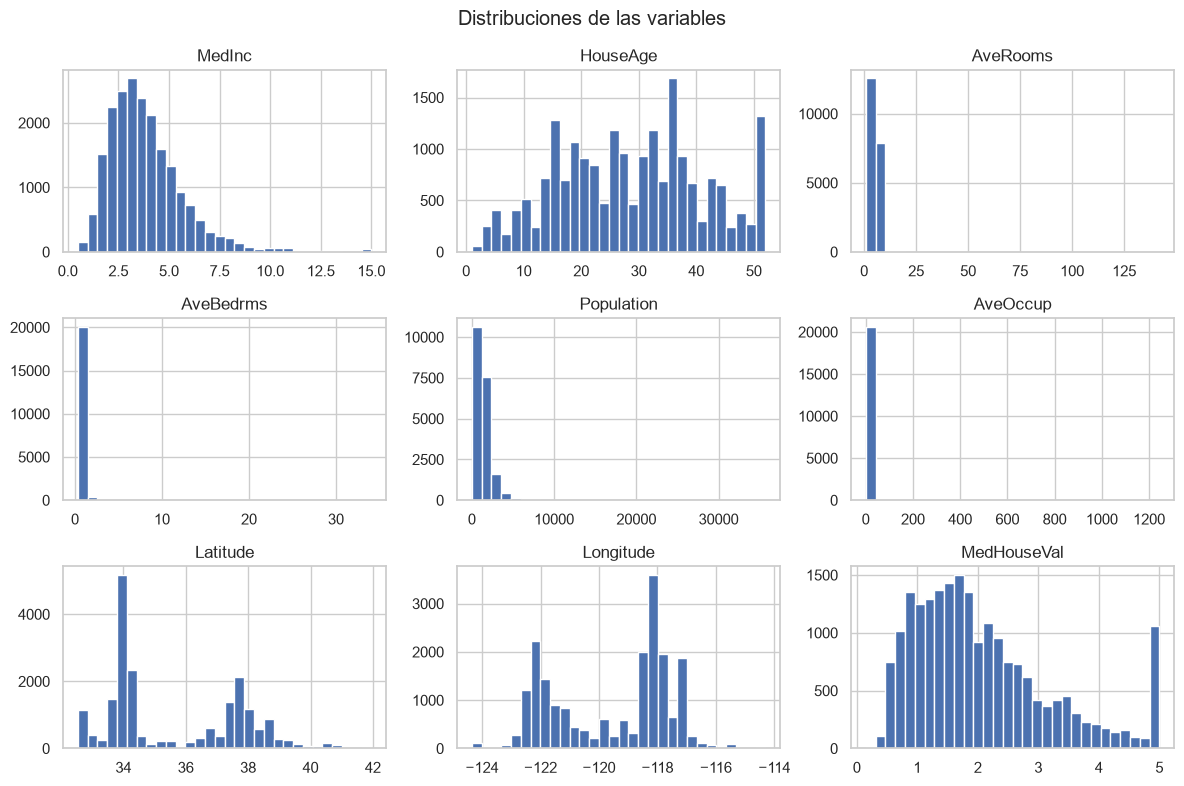

In [8]:
axes=df.hist(bins=30,figsize=(12,8))
plt.suptitle("Distribuciones de las variables")
plt.tight_layout()
plt.show()

In [9]:
(df["MedHouseVal"]>=5).mean()*100##representa el 5 % del total

np.float64(4.8062015503875966)

### Actividad 7 - Examinar asociaciones

<Axes: >

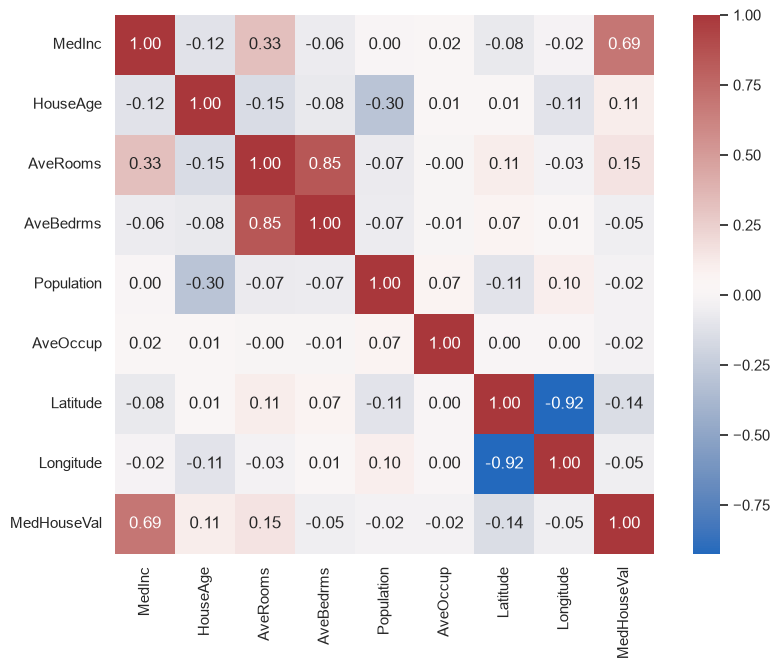

In [10]:
corr= df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr,cmap="vlag",annot=True,fmt=".2f",square=True)

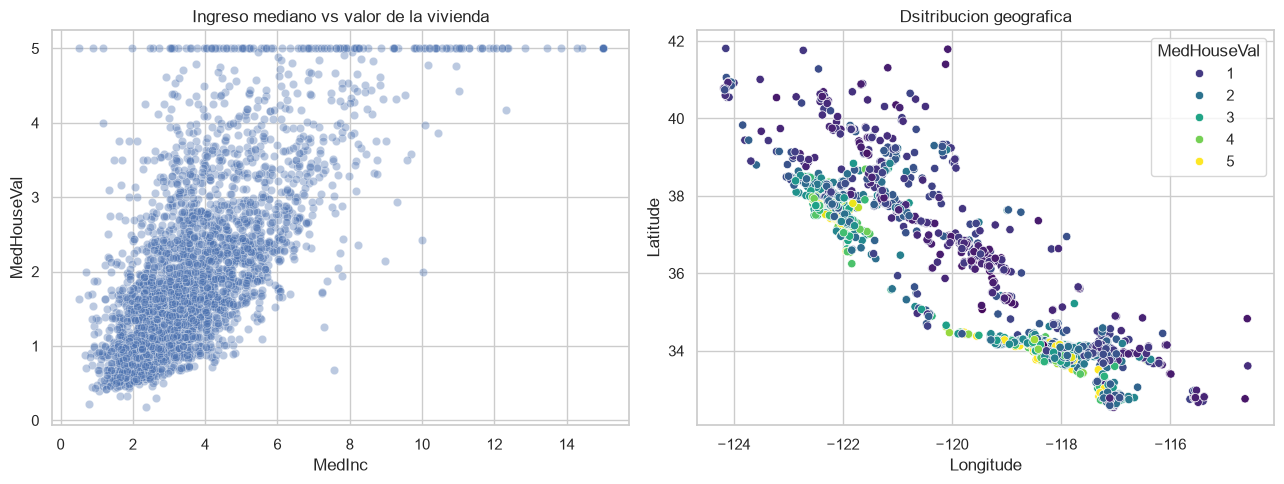

In [11]:
plot_sample= df.sample(n=3000,random_state=RANDOM_STATE)

fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.scatterplot(data=plot_sample,x="MedInc",y="MedHouseVal",alpha=0.38,ax=axes[0])
axes[0].set_title("Ingreso mediano vs valor de la vivienda")

sns.scatterplot(data=plot_sample,x="Longitude",y="Latitude",hue="MedHouseVal",palette="viridis",ax=axes[1])
axes[1].set_title("Dsitribucion geografica")

plt.tight_layout()
plt.show()

### Actividad 8

In [12]:
from sklearn.model_selection import train_test_split

X=df.drop(columns="MedHouseVal")
y=df["MedHouseVal"]

X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Muestras totales:{X.shape}")
print(f"Muestras del train:{X_train.shape}")
print(f"Muestras del test:{X_test.shape}")

print(f"Media train: {y_train.mean():.3f}")
print(f"Media train: {y_test.mean():.3f}")

Muestras totales:(20640, 8)
Muestras del train:(16512, 8)
Muestras del test:(4128, 8)
Media train: 2.072
Media train: 2.055


### Actividad 9- Construir el pipeline

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [14]:
def make_pipeline(modelo):    
    pipeline= Pipeline(
        [
            (
                "prep", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),## se usa la mediana porque es mas robusta ante valores atipicos
                    ("scaler", StandardScaler())
                ])
            ),
            (
                ("model",modelo)
            )
        ]
    )
    return pipeline

prepro_pipeline = make_pipeline(LinearRegression()).named_steps["prep"]
prepro_pipeline.fit(X_train)

print("means:",prepro_pipeline.named_steps["scaler"].mean_)
print("std:",prepro_pipeline.named_steps["scaler"].scale_)

X_train_scaled=prepro_pipeline.transform(X_train) #para scalar 

means: [ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02]
std: [1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00]


In [15]:
stats_df=pd.DataFrame({
    "media":X_train_scaled.mean(axis=0),
    "std":X_train_scaled.std(axis=0)

},index=X_train.columns)

stats_df.round(3)

,media,std
MedInc,-0.0,1.0
HouseAge,-0.0,1.0
AveRooms,0.0,1.0
AveBedrms,-0.0,1.0
Population,0.0,1.0
AveOccup,0.0,1.0
Latitude,0.0,1.0
Longitude,0.0,1.0


### Actividad 10-Establecer una linea base

In [16]:
def get_metricas(nombre,model,X_test,y_test):
    y_pred= model.predict(X_test)
    return{
        "modelo": nombre,
        "MAE":mean_absolute_error(y_test,y_pred),
        "RMSE": root_mean_squared_error(y_test,y_pred),
        "R2": r2_score(y_test,y_pred)
    }

baseline=DummyRegressor(strategy="mean")
baseline.fit(X_train,y_train)
baseline_metrics=get_metricas("baseline (media)", baseline, X_test, y_test)

pd.DataFrame([baseline_metrics]).set_index("modelo").round(3)

,MAE,RMSE,R2
modelo,,,
baseline (media),0.906,1.145,-0.0


### Actividad 11- Ajustar regresion lineal

In [17]:
ols_pipeline=make_pipeline(LinearRegression())
ols_pipeline.fit(X_train,y_train)

ols_metrics=get_metricas("OLS",ols_pipeline,X_test,y_test)

pd.DataFrame([baseline_metrics,ols_metrics]).set_index("modelo").round(3)


,MAE,RMSE,R2
modelo,,,
baseline (media),0.906,1.145,-0.000
OLS,0.533,0.746,0.576


### Actividad 13- Interpretar coeficientes y residuos

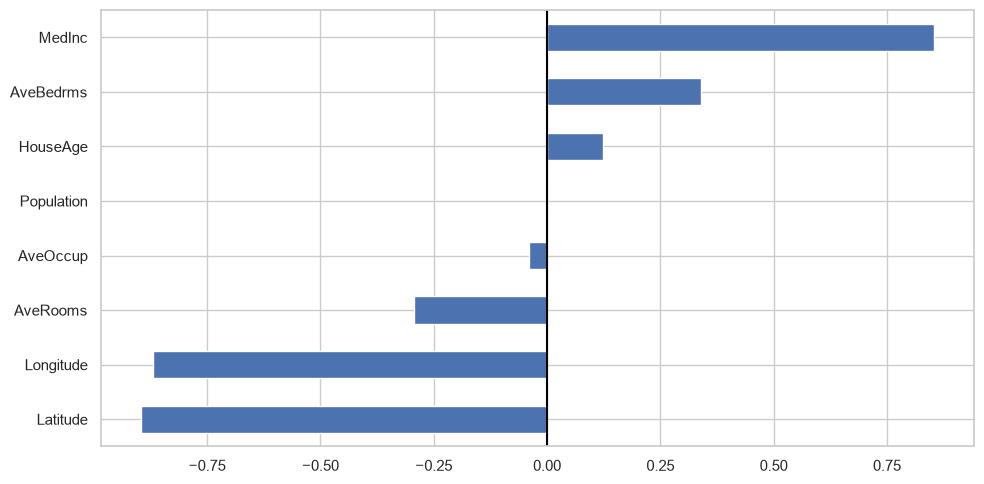

Latitude     -0.896929
Longitude    -0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms     -0.294410
HouseAge      0.122546
AveOccup     -0.040829
Population   -0.002308
dtype: float64

In [18]:
sk_model=ols_pipeline.named_steps["model"]
coef_ols=pd.Series(sk_model.coef_, index=X.columns)
coef_ols.sort_values().plot(kind="barh",figsize=(10,5))
plt.axvline(0,color="black")
plt.tight_layout()
plt.show()

coef_ols.sort_values(key=np.abs,ascending=False)

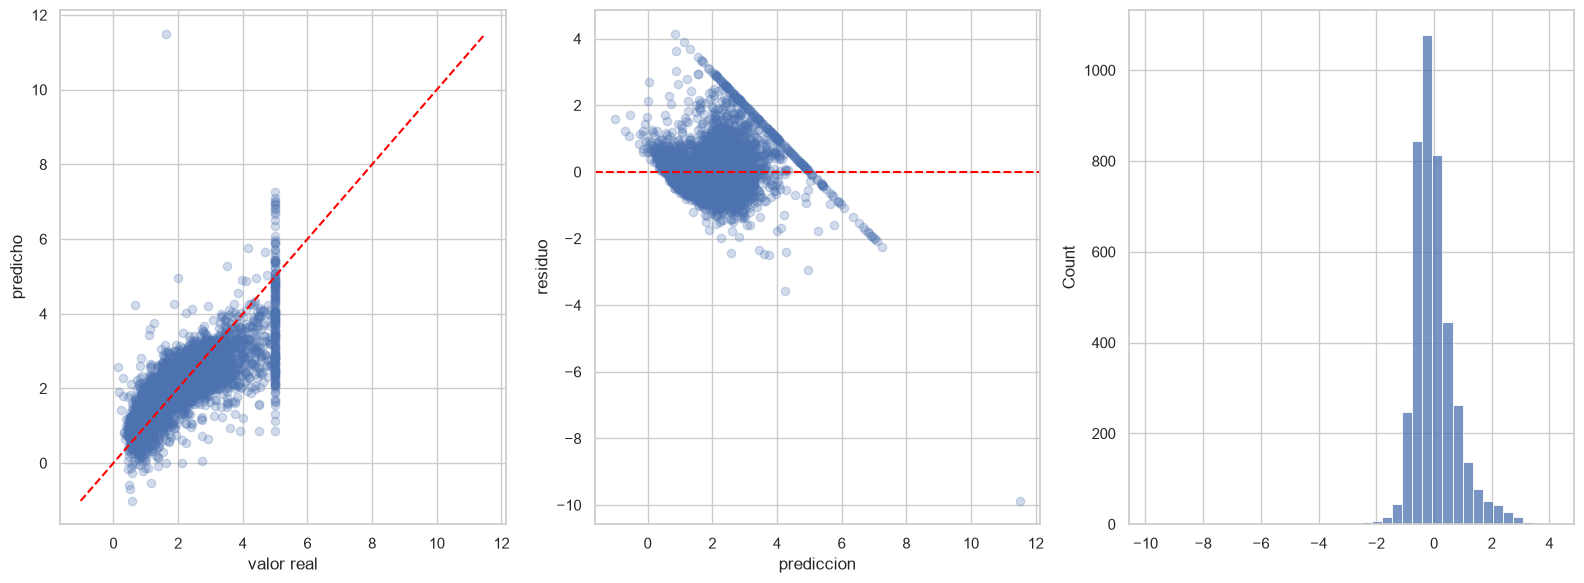

In [19]:
y_preds_ols=ols_pipeline.predict(X_test)
reisduos=y_test.to_numpy()-y_preds_ols

fig,axes=plt.subplots(1,3,figsize=(16,6))
axes[0].scatter(y_test,y_preds_ols,alpha=0.25)
lims=[min(y_test.min(),y_preds_ols.min()),max(y_test.max(),y_preds_ols.max())]
axes[0].plot(lims,lims,'--',color='red')
axes[0].set(xlabel="valor real",ylabel="predicho")

axes[1].scatter(y_preds_ols,reisduos,alpha=0.25)
axes[1].axhline(0,color="red",linestyle='--')####lo que esta arriba indica que dio un valor mayor y lo menor es que dio un menor valor
axes[1].set(xlabel="prediccion",ylabel="residuo")

sns.histplot(reisduos,bins=40)

plt.tight_layout()
plt.show()##se observa que no es perfecto y como lo mostraba el error

### Actividad 15 / 16 / 17 / 18 / 19

In [20]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

# validacion cruzada ---se divide en 5 el data test 
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "ridge": GridSearchCV(###grilla de busqueda , para buscar el alpha 
        make_pipeline(Ridge()),
        {
            "model__alpha": np.logspace(-4, 3, 20)#alpha si es 0 es una regresion, cuan mas grande es lo coeficiente tienden a 0
        },
        scoring="neg_root_mean_squared_error",#para miminizar el error, es la metrica que vamos a maximizar
        cv=cv,
        n_jobs=-1
    ),

    "lasso": GridSearchCV(
        make_pipeline(Lasso(max_iter=50000)),
        {
            "model__alpha": np.logspace(-4, 1, 20)
        },
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ),

    "elasticnet": GridSearchCV(
        make_pipeline(ElasticNet()),
        {
            "model__alpha": np.logspace(-4, 1, 20),
            "model__l1_ratio": (0.1, 0.5, 0.9)
        },
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ),
}

for name, model in models.items():### para ver como resulta cada uno en la data de train no la de test
    model.fit(X_train, y_train)### fit para entrenar
    print(f"{name} | mejor RMSE={-model.best_score_:.6f} best_params:{model.best_params_}")

ridge | mejor RMSE=0.720509 best_params:{'model__alpha': np.float64(2.6366508987303554)}
lasso | mejor RMSE=0.720494 best_params:{'model__alpha': np.float64(0.0006158482110660267)}
elasticnet | mejor RMSE=0.720496 best_params:{'model__alpha': np.float64(0.0006158482110660267), 'model__l1_ratio': 0.9}


In [21]:
ols_metrics

{'modelo': 'OLS',
 'MAE': 0.5332001304956565,
 'RMSE': 0.7455813830127764,
 'R2': 0.5757877060324508}

In [22]:
rows = [baseline_metrics, ols_metrics]## para ver las metricas en el data test 
for name, model in models.items():
    rows.append(
        get_metricas(name, model.best_estimator_, X_test, y_test)
    )

pd.DataFrame(rows).set_index("modelo").sort_values("RMSE")

,MAE,RMSE,R2
modelo,,,
lasso,0.533161,0.744991,0.576459
elasticnet,0.533158,0.745026,0.576420
ridge,0.533182,0.745517,0.575861
OLS,0.533200,0.745581,0.575788
baseline (media),0.906069,1.144856,-0.000219


### Actividad 20

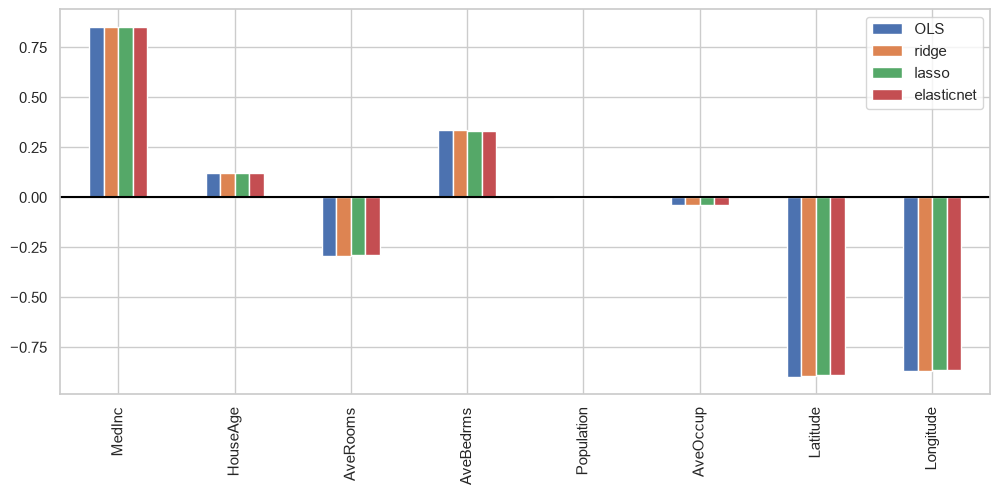

In [23]:
coef_models = {
    "OLS": ols_pipeline.named_steps["model"].coef_##para obtener los pesos que le dio a todos los coeficientes
}

for name, model in models.items():
    coef_models[name] = model.best_estimator_.named_steps["model"].coef_

coef_table = pd.DataFrame(coef_models, index=X.columns)
coef_table.plot(kind="bar", figsize=(12, 5))
plt.axhline(0, color="black")
plt.show()

In [24]:
coef_table### se ve que ols lo resuelve bien y los otros no lo mejoran mucho , y se usaria ese en el caso de usarlo

,OLS,ridge,lasso,elasticnet
MedInc,0.854383,0.854234,0.851160,0.851427
HouseAge,0.122546,0.122751,0.123040,0.123069
AveRooms,-0.294410,-0.293883,-0.286329,-0.286939
AveBedrms,0.339259,0.338596,0.331131,0.331694
Population,-0.002308,-0.002241,-0.001540,-0.001591
AveOccup,-0.040829,-0.040839,-0.040251,-0.040313
Latitude,-0.896929,-0.894925,-0.890076,-0.889992
Longitude,-0.869842,-0.867812,-0.862595,-0.862541


### Actividad 21

In [25]:
muestra = X_test.iloc[[5]]
valor_real = y_test.iloc[5] * 100000

pred = ols_pipeline.predict(muestra) * 100000
print("Valor predecido: ", pred[0], "Valor real: ", valor_real)

Valor predecido:  201175.3673249894 Valor real:  158700.0


### Actividad 22

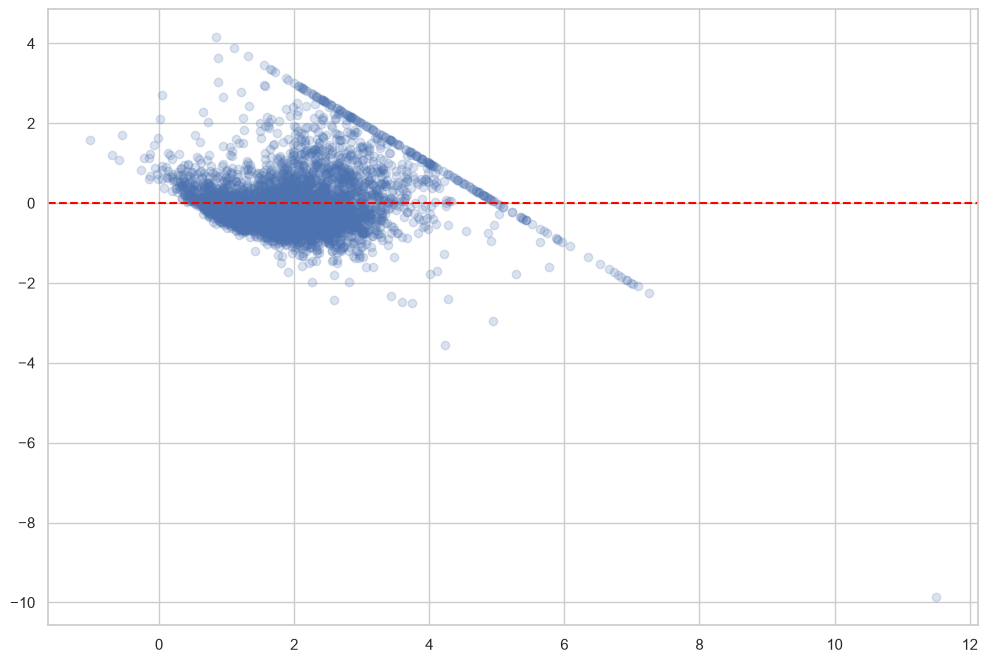

Error promedio de 20% más barato: 0.102
Error promedio de 20% más caros: 0.113


In [26]:

preds = ols_pipeline.predict(X_test)
residuos = (y_test - preds).to_numpy()

plt.figure(figsize=(12, 8))
plt.scatter(preds, residuos, alpha=0.2)
plt.axhline(0, color="red", linestyle="--")
plt.show()

orden = np.argsort(preds)
n = len(preds) // 5

print(f"Error promedio de 20% más barato: {residuos[orden[:n]].mean():.3f}")
print(f"Error promedio de 20% más caros: {residuos[orden[-n:]].mean():.3f}")

### Actividad 23

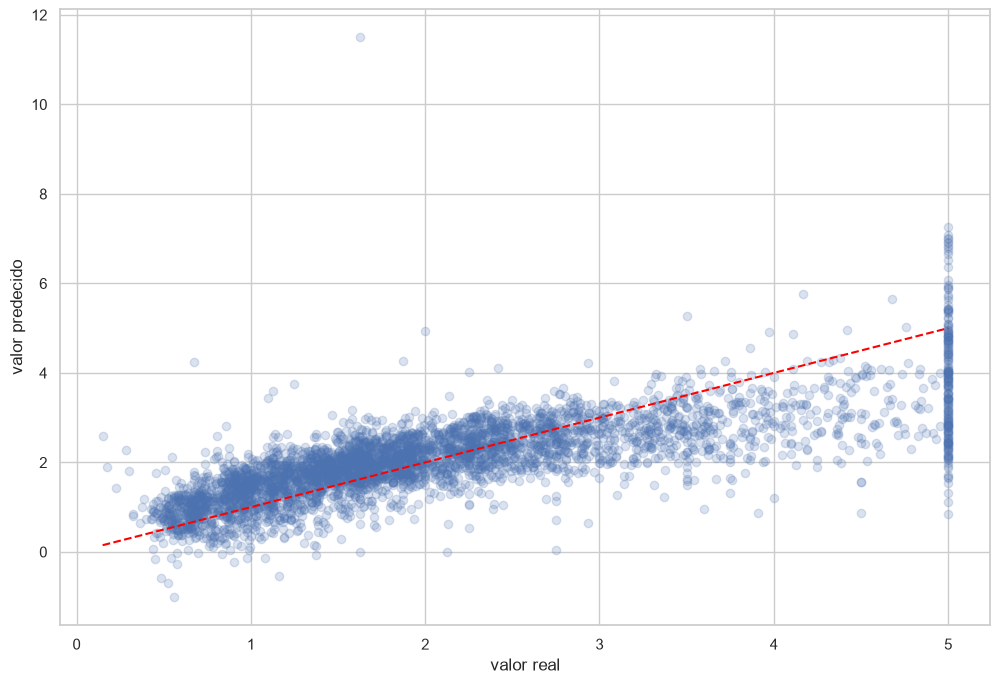

In [27]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, alpha=0.2)

lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "--", color="red")
plt.xlabel("valor real")
plt.ylabel("valor predecido")
plt.show()

In [28]:
muestras_tope_5 = (y_test >= 5.0).mean() * 100
muestras_tope_5

np.float64(4.457364341085271)

### Actividad 24

In [29]:
from sklearn.preprocessing import SplineTransformer##  se divide en partes y para cada parte se ve la curva que cumple mejor
from sklearn.pipeline import make_pipeline

splines = make_pipeline(
    SplineTransformer(n_knots=6),
    Ridge(alpha=1.0)
)
splines.fit(X_train, y_train)

r2_splines = splines.score(X_test, y_test)
splines_metrics = get_metricas("splines", splines, X_test, y_test)

print(f"R2 OLS: {ols_metrics["R2"]}")
print(f"R2 SPLINES: {r2_splines}")

print(f"MAE OLS: {ols_metrics["MAE"]}")
print(f"MAE SPLINES: {splines_metrics["MAE"]}")

print(f"RMSE OLS: {ols_metrics["RMSE"]}")
print(f"RMSE SPLINES: {splines_metrics["RMSE"]}")

print("Ganancia:", abs(ols_metrics["R2"] - r2_splines))

# splines_metrics

R2 OLS: 0.5757877060324508
R2 SPLINES: 0.6336772343948942
MAE OLS: 0.5332001304956565
MAE SPLINES: 0.4979303431499082
RMSE OLS: 0.7455813830127764
RMSE SPLINES: 0.6928438792274687
Ganancia: 0.05788952836244343


In [30]:
filas = []
tramos = [3, 6, 10, 15, 20, 30, 40, 50, 100, 200, 300, 500, 800, 1000]

for tramo in tramos:
    modelo = make_pipeline(SplineTransformer(n_knots=tramo), Ridge(alpha=1))
    modelo.fit(X_train, y_train)
    # exps.append(get_metricas(f"tramo_{tramo}", modelo, X_test, y_test))
    filas.append({
        "tramos": tramo,
        "r2_train": modelo.score(X_train, y_train),
        "rmse_train": root_mean_squared_error(y_train, modelo.predict(X_train)),
        "r2_test": modelo.score(X_test, y_test),
        "rmse_test": root_mean_squared_error(y_test, modelo.predict(X_test))
    })

filas = pd.DataFrame(filas)

In [31]:
filas# se revisa en r2 test como con 200 tramos llega a su punto maximo y de ahi baja

,tramos,r2_train,rmse_train,r2_test,rmse_test
0,3,0.638084,0.695558,0.613808,0.711386
1,6,0.663301,0.670889,0.633677,0.692844
2,10,0.682131,0.651860,0.649023,0.678177
3,15,0.699031,0.634294,0.665834,0.661736
4,20,0.710972,0.621584,0.684397,0.643093
5,30,0.726829,0.604293,0.704509,0.622265
6,40,0.739639,0.589953,0.719837,0.605911
7,50,0.753010,0.574605,0.735715,0.588491
8,100,0.773035,0.550820,0.753924,0.567855
9,200,0.781861,0.540003,0.759363,0.561545


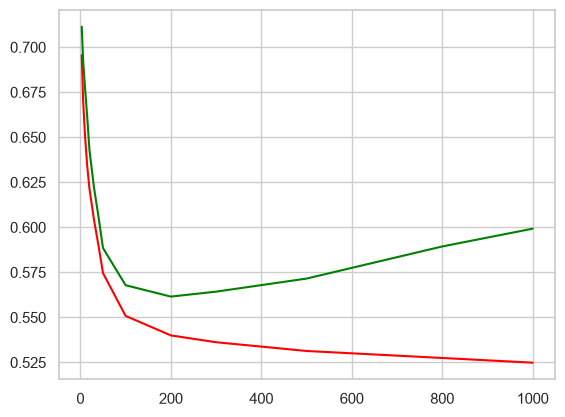

In [32]:
plt.plot(tramos, filas["rmse_train"].to_numpy(), color="red")
plt.plot(tramos, filas["rmse_test"].to_numpy(), color="green")

### Actividad 26

In [33]:
from sklearn.neighbors import KNeighborsRegressor

vecinos = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=10)
)

vecinos.fit(X_train, y_train)
r2_vecinos = vecinos.score(X_test, y_test)

print(f"r2_lineal: ", ols_metrics["R2"])
print(f"r2_splines: ", r2_splines)
print(f"r2_vecinos: ", r2_vecinos)

r2_lineal:  0.5757877060324508
r2_splines:  0.6336772343948942
r2_vecinos:  0.678313939893506


### Actividad 27

In [34]:
vecinos_sin_scalar = make_pipeline(### sin escalamiento knn sufre mucho para asociar 
    KNeighborsRegressor(n_neighbors=10)
)
vecinos_sin_scalar.fit(X_train, y_train)
r2_vecinos_sin_scalar = vecinos_sin_scalar.score(X_test, y_test)

print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_vecinos_sin_standarizacion: ", r2_vecinos_sin_scalar)

r2_vecinos_con_standarizacion:  0.678313939893506
r2_vecinos_sin_standarizacion:  0.15538785394268484


In [35]:
X_train.std().sort_values(ascending=False)

Population    1137.056380
HouseAge        12.602499
AveOccup        11.578744
AveRooms         2.387375
Latitude         2.136665
Longitude        2.005654
MedInc           1.904294
AveBedrms        0.433215
dtype: float64

### Actividad 28

In [36]:
filas = []
vecinos = [1, 5, 10, 25, 50, 100, 150, 200]

for k in vecinos:
    modelo = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    modelo.fit(X_train, y_train)
    filas.append({
        "n_neighbors": k,
        "r2_entrenamiento": modelo.score(X_train, y_train),
        "rmse_train": root_mean_squared_error(y_train, modelo.predict(X_train)),
        "r2_prueba": modelo.score(X_test, y_test),
        "rmse_test": root_mean_squared_error(y_test, modelo.predict(X_test))
    })

filas = pd.DataFrame(filas)
filas

,n_neighbors,r2_entrenamiento,rmse_train,r2_prueba,rmse_test
0,1,1.000000,0.000000,0.489463,0.817932
1,5,0.796898,0.521059,0.670010,0.657588
2,10,0.754979,0.572310,0.678314,0.649261
3,25,0.714814,0.617439,0.674508,0.653091
4,50,0.688864,0.644919,0.659440,0.668037
5,100,0.665466,0.668728,0.642517,0.684433
6,150,0.650153,0.683862,0.630345,0.695988
7,200,0.638428,0.695227,0.619545,0.706082


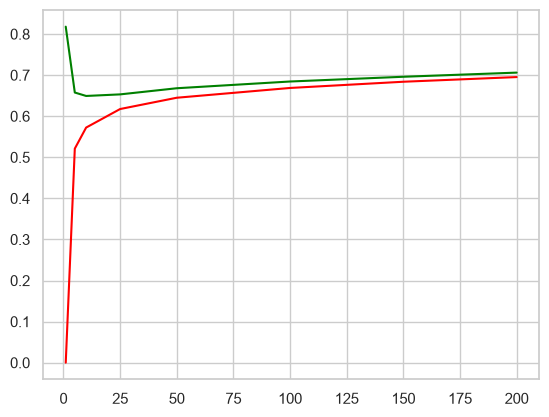

In [37]:
plt.plot(vecinos, filas["rmse_train"].to_numpy(), color="red")
plt.plot(vecinos, filas["rmse_test"].to_numpy(), color="green")

### Actividad 29

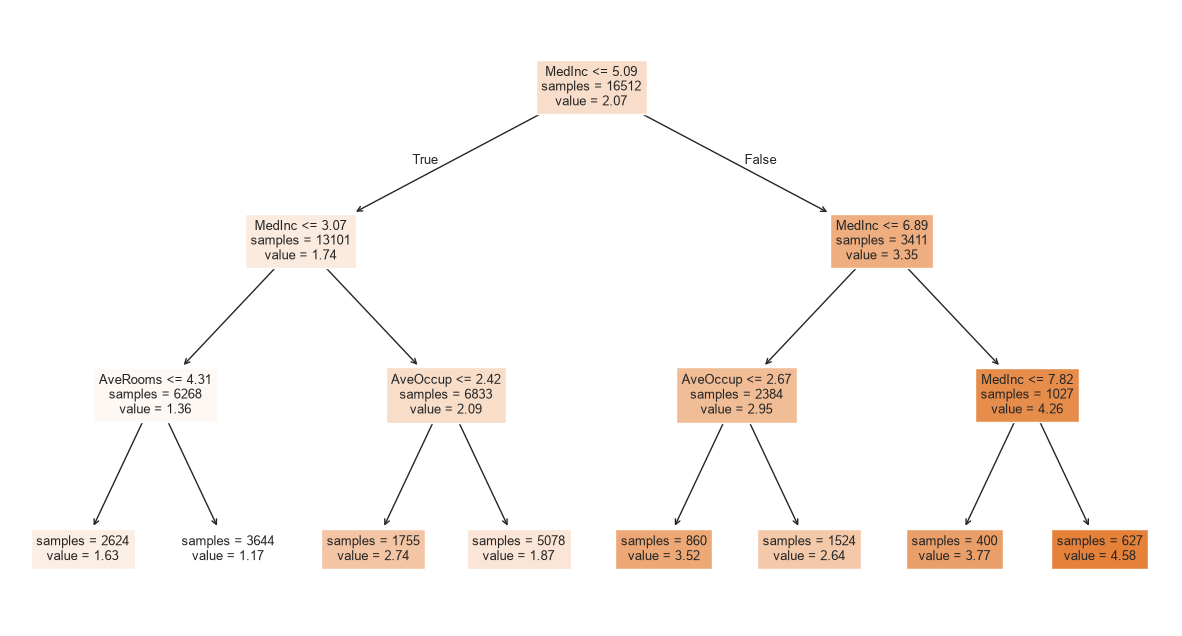

In [38]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

arbol_3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
arbol_3.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(arbol_3, feature_names=list(X_train.columns), filled=True, fontsize=9, impurity=False, precision=2)
plt.show()

In [39]:
r2_arbol_3 = arbol_3.score(X_test, y_test) ### se observa que tiene un valor muy bajo
print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948942
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219


In [40]:
arbol_5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)### se prubea con mayor profundidad
arbol_5.fit(X_train, y_train)

r2_arbol_5 = arbol_5.score(X_test, y_test)
print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)
print(f"r2_arbol_5: ", r2_arbol_5)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948942
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219
r2_arbol_5:  0.5997321244428706


In [41]:

arbol_sin_limite = DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE)## arbol sin limite
arbol_sin_limite.fit(X_train, y_train)

r2_arbol_sin_limite = arbol_sin_limite.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)
print(f"r2_arbol_5: ", r2_arbol_5)
print(f"r2_arbol_sin_limite: ", r2_arbol_sin_limite)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948942
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219
r2_arbol_5:  0.5997321244428706
r2_arbol_sin_limite:  0.622823312540521


In [42]:
arbol_sin_limite.get_depth()### crece hasta un cierto numero que va analizando internamente

34

### Actividad 31

In [43]:
from sklearn.ensemble import RandomForestRegressor

bosque = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)

bosque.fit(X_train, y_train)

r2_bosque = bosque.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print("R2 bosque: ", r2_bosque)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948942
r2_vecinos_con_standarizacion:  0.678313939893506
R2 bosque:  0.8063448218258034


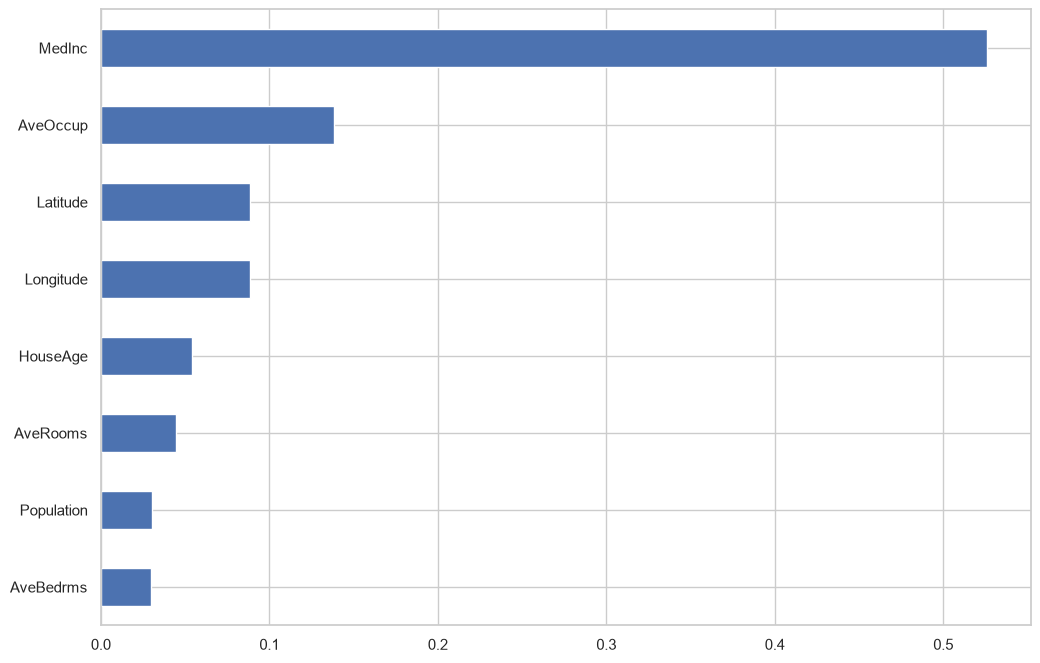

In [44]:
importancias = pd.Series(bosque.feature_importances_, index=X_train.columns)
importancias.sort_values().plot(kind="barh", figsize=(12,8))
plt.show()

In [45]:
importancias.sort_values()

AveBedrms     0.029688
Population    0.030607
AveRooms      0.044596
HouseAge      0.054259
Longitude     0.088417
Latitude      0.088634
AveOccup      0.138062
MedInc        0.525737
dtype: float64

### ACtividad 32

In [46]:
from sklearn.ensemble import HistGradientBoostingRegressor#este cada arbol selecciona las muestras que fallo y le pasa al siguiente arbol 
import time###############################################y esto se hace sucesivamente para que cada uno vaya mejorando en comparacion al anterior

start_time = time.perf_counter()
boosting = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
boosting.fit(X_train, y_train)
end_time = time.perf_counter()

tiempo_total = end_time - start_time

r2_boosting = boosting.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print("R2 bosque: ", r2_bosque)
print("R2 boosting: ", r2_boosting)
print(f"r2_arbol_sin_limite: ", r2_arbol_sin_limite)
print("Tiempo entrenamiento de boosting: ", tiempo_total)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948942
r2_vecinos_con_standarizacion:  0.678313939893506
R2 bosque:  0.8063448218258034
R2 boosting:  0.8347108310143663
r2_arbol_sin_limite:  0.622823312540521
Tiempo entrenamiento de boosting:  0.4211680000007618


In [47]:
muestra_test = X_test.iloc[0, :].to_numpy().reshape(1,-1)
etiqueta_test = y_test.iloc[0]

pred_ols = ols_pipeline.predict(muestra_test)
pred_boosting = boosting.predict(muestra_test)

c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\SAHUA\Documents\datascience-g8\01-python-intro\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print("Valor real: ", etiqueta_test * 100000)
print("Prediccion_lineal: ", pred_ols * 100000)
print("Prediccion_boosting: ", pred_boosting * 100000)

Valor real:  47700.0
Prediccion_lineal:  [71912.28416019]
Prediccion_boosting:  [57313.49339984]


: 